This is a companion notebook for the book [Deep Learning with Python, Second Edition](https://www.manning.com/books/deep-learning-with-python-second-edition?a_aid=keras&a_bid=76564dff).


# Getting started with neural networks: Classification and regression

## Example 1: Classifying movie reviews: A binary classification example

### The IMDB dataset

**Loading the IMDB dataset**

In [1]:
import keras
keras.__version__

C:\Users\enriq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\enriq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\enriq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Pyt

'3.12.0'

In [2]:
# Download the IMDB dataset: 50K polarized reviews with 25K for training and
# 25K for testing, each set with 50% positive and 50% negative reviews.
# Argument 10000: keep only the 10K most freq. words on the dataset
from tensorflow.keras.datasets import imdb
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(
    num_words=10000)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


In [3]:
# Words are encoded as entries in a dictionary.
# A review is coded by the indices of the words it contains.
# Note that each entry may have a varying number of words (indices)
train_data[0]

[1,
 14,
 22,
 16,
 43,
 530,
 973,
 1622,
 1385,
 65,
 458,
 4468,
 66,
 3941,
 4,
 173,
 36,
 256,
 5,
 25,
 100,
 43,
 838,
 112,
 50,
 670,
 2,
 9,
 35,
 480,
 284,
 5,
 150,
 4,
 172,
 112,
 167,
 2,
 336,
 385,
 39,
 4,
 172,
 4536,
 1111,
 17,
 546,
 38,
 13,
 447,
 4,
 192,
 50,
 16,
 6,
 147,
 2025,
 19,
 14,
 22,
 4,
 1920,
 4613,
 469,
 4,
 22,
 71,
 87,
 12,
 16,
 43,
 530,
 38,
 76,
 15,
 13,
 1247,
 4,
 22,
 17,
 515,
 17,
 12,
 16,
 626,
 18,
 2,
 5,
 62,
 386,
 12,
 8,
 316,
 8,
 106,
 5,
 4,
 2223,
 5244,
 16,
 480,
 66,
 3785,
 33,
 4,
 130,
 12,
 16,
 38,
 619,
 5,
 25,
 124,
 51,
 36,
 135,
 48,
 25,
 1415,
 33,
 6,
 22,
 12,
 215,
 28,
 77,
 52,
 5,
 14,
 407,
 16,
 82,
 2,
 8,
 4,
 107,
 117,
 5952,
 15,
 256,
 4,
 2,
 7,
 3766,
 5,
 723,
 36,
 71,
 43,
 530,
 476,
 26,
 400,
 317,
 46,
 7,
 4,
 2,
 1029,
 13,
 104,
 88,
 4,
 381,
 15,
 297,
 98,
 32,
 2071,
 56,
 26,
 141,
 6,
 194,
 7486,
 18,
 4,
 226,
 22,
 21,
 134,
 476,
 26,
 480,
 5,
 144,
 30,
 5535,
 18,

In [4]:
# Labels: 0 -> Negative and 1 -> Positive
train_labels[0]

np.int64(1)

In [5]:
# Because we’re restricting ourselves to the top 10,000 most frequent words, no word index will exceed 10,000:
max([max(sequence) for sequence in train_data])

9999

**Decoding reviews back to text**

In [6]:
# word_index is a dictionary mapping words to an integer index
word_index = imdb.get_word_index()
reverse_word_index = dict(
    [(value, key) for (key, value) in word_index.items()])
decoded_review = " ".join(
    [reverse_word_index.get(i - 3, "?") for i in train_data[0]])

# The '-3' is because the indices are offset by 3 cause 0, 1, 2 are reserved for "padding", "start of sequence" and "unknown"

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 2s 1us/step


In [7]:
print(reverse_word_index.get(120))

show


In [8]:
decoded_review

"? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you th

In [10]:
# Decode a negative review
# Find the first negative review (label = 0)
negative_index = train_labels.tolist().index(0)

# Decode it back to text
decoded_negative_review = " ".join(
    [reverse_word_index.get(i - 3, "?") for i in train_data[negative_index]])
decoded_negative_review

"? big hair big boobs bad music and a giant safety pin these are the words to best describe this terrible movie i love cheesy horror movies and i've seen hundreds but this had got to be on of the worst ever made the plot is paper thin and ridiculous the acting is an abomination the script is completely laughable the best is the end showdown with the cop and how he worked out who the killer is it's just so damn terribly written the clothes are sickening and funny in equal ? the hair is big lots of boobs ? men wear those cut ? shirts that show off their ? sickening that men actually wore them and the music is just ? trash that plays over and over again in almost every scene there is trashy music boobs and ? taking away bodies and the gym still doesn't close for ? all joking aside this is a truly bad film whose only charm is to look back on the disaster that was the 80's and have a good old laugh at how bad everything was back then"

### Preparing the data

The inputs are not amenable for a NN, since they have different lengths.

How to fix this?

Option 1: Pad all inputs into an integer tensor of shape (samples, max_length)

Option 2: Turn each example into a 10K binary vector, where each position correspond to the index of a word, with a '1' indicating the word is present in the review, and '0' that is not present.

We will go with **OPTION 2**.

**Encoding the integer sequences via multi-hot encoding**

In [11]:
import numpy as np
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        for j in sequence:
            results[i, j] = 1.
    return results
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

In [12]:
x_train[0]

array([0., 1., 1., ..., 0., 0., 0.], shape=(10000,))

In [13]:
# Vectorize labels
y_train = np.asarray(train_labels).astype("float32")
y_test = np.asarray(test_labels).astype("float32")

### Building your model

**Model definition**

In [14]:
# Define a model with 2 hidden layers of 16 neurons each and ReLu activation function
# Add the appropiate output layer (think of number of neurons and activation function)
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(16, activation="relu", input_shape=(10000,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

C:\Users\enriq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Compiling the model**

In [15]:
# Compile the model: optimizer rmsprop, loss (which loss should you use?) and Accuracy metric.
model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

### Validating your approach

**Setting aside a validation set**

In [16]:
# Set apart 10K instances of the training set for validation
# Call the sets: x_val; partial_x_train; y_val; partial_y_train
x_val = x_train[:10000]
partial_x_train = x_train[10000:]
y_val = y_train[:10000]
partial_y_train = y_train[10000:]

**Training your model**

In [17]:
# Fit the model specifying training and validation data; 20 epochs; batch size of 512
history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7637 - loss: 0.5641 - val_accuracy: 0.8572 - val_loss: 0.4316
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8838 - loss: 0.3543 - val_accuracy: 0.8810 - val_loss: 0.3313
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9096 - loss: 0.2633 - val_accuracy: 0.8821 - val_loss: 0.3006
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9305 - loss: 0.2100 - val_accuracy: 0.8872 - val_loss: 0.2800
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9424 - loss: 0.1772 - val_accuracy: 0.8807 - val_loss: 0.3030
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9540 - loss: 0.1478 - val_accuracy: 0.8695 - val_loss: 0.3289
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9596 - loss: 0.1289 - val_accuracy: 0.8820 - val_loss: 0.2939
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9681 - loss: 0.1093 - val_accuracy: 0.8724 - val_loss

In [18]:
# The call to model.fit returns a History object with member history, which is
# a dictionary containing almost everything that happened during training
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

**Plotting the training and validation loss**

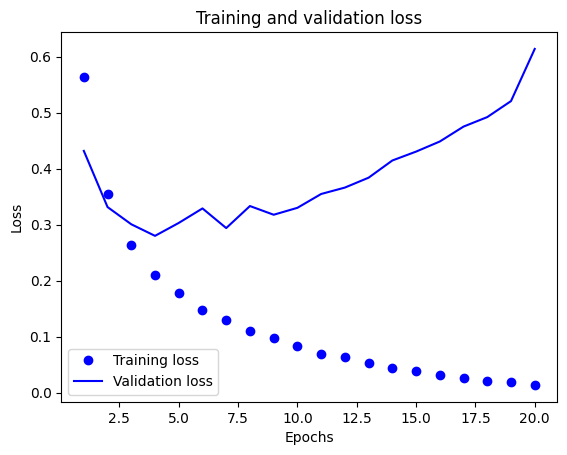

In [19]:
import matplotlib.pyplot as plt
history_dict = history.history
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "bo", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

**Plotting the training and validation accuracy**

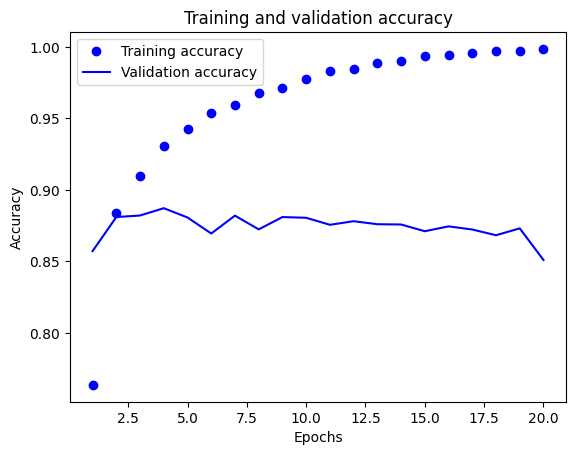

In [20]:
# Your code here
acc_values = history_dict["accuracy"]
val_acc_values = history_dict["val_accuracy"]
plt.plot(epochs, acc_values, "bo", label="Training accuracy")
plt.plot(epochs, val_acc_values, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

**Retraining a model from scratch**

In [21]:
# Retrain the model for 4 epochs using ALL the training data
model = keras.Sequential([
    layers.Dense(16, activation="relu", input_shape=(10000,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])
history = model.fit(x_train, y_train, epochs=4, batch_size=512)

Epoch 1/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7946 - loss: 0.4980
Epoch 2/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9000 - loss: 0.2969
Epoch 3/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9182 - loss: 0.2282
Epoch 4/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9331 - loss: 0.1919


In [22]:
# Evaluate the model on the test set.
# What accuracy do you obtain?
results = model.evaluate(x_test, y_test)
print(f"Test loss: {results[0]}")
print(f"Test accuracy: {results[1]}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8880 - loss: 0.2789
Test loss: 0.278864324092865
Test accuracy: 0.8879600167274475


### Using a trained model to generate predictions on new data

In [24]:
model.predict(x_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


array([[0.20849992],
       [0.9980892 ],
       [0.8565996 ],
       ...,
       [0.09327357],
       [0.07915823],
       [0.68063223]], shape=(25000, 1), dtype=float32)

Why don't we get predictions equal to 0 or 1?

Answer: 

No obtenemos predicciones iguales a 0 o 1 porque la capa de salida usa una función de activación sigmoid, que produce valores continuos entre 0 y 1. 
Estos valores representan la probabilidad de que la review sea positiva. 

Por ejemplo:
    Una predicción de 0.95 significa que el modelo tiene 95% de confianza de que la review es positiva
    Una predicción de 0.12 significa que el modelo tiene 12% de confianza de que es positiva (o 88% de que es negativa)

Para convertir a predicciones binarias (0 o 1), necesitaríamos aplicar un umbral (típicamente 0.5):
    Si predicción ≥ 0.5 → clasificar como 1 (positivo)
    Si predicción < 0.5 → clasificar como 0 (negativo)

### Further experiments

- Try using 1 or 3 hidden layers instead
- Try using more or fewer neurons per layer
- Try using tanh as activation function istead of ReLu

## Example 2: Classifying newswires: A multiclass classification example

### The Reuters dataset

The goal is to classify Reuters newswires into 46 mutually exclusive topics. Because we have many classes, this problem is an instance of multi-class classification, and because each data point should be classified into only one category, the problem is more specifically an instance of single-label multiclass classification. If each data point could belong to multiple categories (in this case, topics), we’d be facing a multilabel multiclass classification problem.

**Loading the Reuters dataset**

The Reuters dataset is a set of short newswires and their topics, published by Reuters in 1986.

In [ ]:
from tensorflow.keras.datasets import reuters
(train_data, train_labels), (test_data, test_labels) = reuters.load_data(
    num_words=10000)

# As with the IMDB dataset, the argument num_words=10000 restricts the data
# to the 10,000 most frequently occurring words found in the data.

In [ ]:
# check number of training examples
len(train_data)

In [ ]:
# check number of testing examples
len(test_data)

In [ ]:
# Let's take a look at one example
train_data[10]

**Decoding newswires back to text**

In [ ]:
# How to decode it back to words
word_index = reuters.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
decoded_newswire = " ".join([reverse_word_index.get(i - 3, "?") for i in
    train_data[0]])

In [ ]:
train_labels[10]

### Preparing the data

**Encoding the input data**

In [ ]:
# Vectorize the data
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

**Encoding the labels**

In [ ]:
# Convert the labels to one-hot encoding vectors
from tensorflow.keras.utils import to_categorical


### Building your model

**Model definition**

In [ ]:
# Create a model with two hidden layers, each with 64 neurons and ReLu activaiton function
# What should the last layer be?


**Compiling the model**

In [ ]:
# Compile the model with RMSprop.
# Think about the right loss and metric to use


### Validating your approach

**Setting aside a validation set**

In [ ]:
# Set apart 1000 samples for validation from the training set


**Training the model**

In [ ]:
# Train the model on the lef-out training data (wo the validation), and validate
# on the validation set.
# Train for 20 epochs and batch size of 512


**Plotting the training and validation loss**

In [ ]:
# Plot the training and validation loss


**Plotting the training and validation accuracy**

In [ ]:
# Plot the training and validation accuracy


**Retraining a model from scratch**

In [ ]:
# Train the model on the WHOLE training data and evaluate on the test set


In [ ]:
# What is the accuracy on the test set?


In [ ]:
# What would be the accuracy of a random classifier?


### Generating predictions on new data

In [ ]:
predictions = model.predict(x_test)

In [ ]:
predictions[0].shape

In [ ]:
np.sum(predictions[0])

In [ ]:
np.argmax(predictions[0])

### The importance of having sufficiently large intermediate layers

**A model with an information bottleneck**

In [ ]:
# Generate a model with 64 neurons on the first layer and just 4 on the second
# one (note that we have more than 4 different labels/classes)
# What happens to the accuracy on the test data?


## Example 3: Predicting house prices: A regression example

### The Boston Housing Price dataset

The goal is to predict the median price of homes in a given Boston suburb in the mid-1970s, given data points about the suburb at the time, such as the crime rate, the local property tax rate, and so on. The dataset we’ll use has an interest- ing difference from the two previous examples. It has relatively few data points: only 506, split between 404 training samples and 102 test samples. And each feature in the input data (for example, the crime rate) has a different scale. For instance, some values are proportions, which take values between 0 and 1, others take values between 1 and 12, others between 0 and 100, and so on.

**Loading the Boston housing dataset**

In [ ]:
from tensorflow.keras.datasets import boston_housing
(train_data, train_targets), (test_data, test_targets) = boston_housing.load_data()

In [ ]:
train_data.shape

In [ ]:
test_data.shape

In [ ]:
train_targets

### Preparing the data

It would be problematic to feed into a neural network values that all take wildly different ranges. The model might be able to automatically adapt to such heterogeneous data, but it would definitely make learning more difficult. A widespread best practice for dealing with such data is to do feature-wise normalization: for each feature in the input data (a column in the input data matrix), we subtract the mean of the feature and divide by the standard deviation, so that the feature is centered around 0 and has a unit standard deviation. This is easily done in NumPy.

**Normalizing the data**

In [ ]:
# Normalize the data to have mean 0 and std 1
# Careful with training and test sets!! How should you do it?


### Building your model

**Model definition**

In [ ]:
# Build a model with two hidden layers of 64 neurons each and ReLu activation function
# What shoudl the last layer be?
# Compile the model with RMSProp, MSE loss, and MAE as metric
def build_model():
    model = keras.Sequential([
        layers.Dense(),
        layers.Dense(),
        layers.Dense()
    ])
    model.compile(optimizer=, loss=, metrics=)
    return model

### Validating your approach using K-fold validation

**K-fold validation**

We will do k-fold CV since we have very few samples to train.

In [ ]:
k = 4
num_val_samples = len(train_data) // k
num_epochs = 100
all_scores = []
for i in range(k):
    print(f"Processing fold #{i}")
    val_data = train_data[i * num_val_samples: (i + 1) * num_val_samples]
    val_targets = train_targets[i * num_val_samples: (i + 1) * num_val_samples]
    partial_train_data = np.concatenate(
        [train_data[:i * num_val_samples],
         train_data[(i + 1) * num_val_samples:]],
        axis=0)
    partial_train_targets = np.concatenate(
        [train_targets[:i * num_val_samples],
         train_targets[(i + 1) * num_val_samples:]],
        axis=0)
    model = build_model()
    model.fit(partial_train_data, partial_train_targets,
              epochs=num_epochs, batch_size=16, verbose=0)
    val_mse, val_mae = model.evaluate(val_data, val_targets, verbose=0)
    all_scores.append(val_mae)

In [ ]:
all_scores

In [ ]:
np.mean(all_scores)

The different runs do show different validations scores, from \$1.83K to \$2.70K. The average MAE of \$2,377 is more reliable.

In this case we are off by around \$2,400 which is significant given that the prices range from \$10,000 to \$50,000.

**Saving the validation logs at each fold**

Let’s try training the model a bit longer: 500 epochs. To keep a record of how well the model does at each epoch, we’ll modify the training loop to save the per-epoch validation score log for each fold.

In [ ]:
num_epochs = 500
all_mae_histories = []
for i in range(k):
    print(f"Processing fold #{i}")
    val_data = train_data[i * num_val_samples: (i + 1) * num_val_samples]
    val_targets = train_targets[i * num_val_samples: (i + 1) * num_val_samples]
    partial_train_data = np.concatenate(
        [train_data[:i * num_val_samples],
         train_data[(i + 1) * num_val_samples:]],
        axis=0)
    partial_train_targets = np.concatenate(
        [train_targets[:i * num_val_samples],
         train_targets[(i + 1) * num_val_samples:]],
        axis=0)
    model = build_model()
    history = model.fit(partial_train_data, partial_train_targets,
                        validation_data=(val_data, val_targets),
                        epochs=num_epochs, batch_size=16, verbose=0)
    mae_history = history.history["val_mae"]
    all_mae_histories.append(mae_history)

**Building the history of successive mean K-fold validation scores**

In [ ]:
# We can then compute the average of the per-epoch MAE scores for all folds.
average_mae_history = [
    np.mean([x[i] for x in all_mae_histories]) for i in range(num_epochs)]

**Plotting validation scores**

In [ ]:
plt.plot(range(1, len(average_mae_history) + 1), average_mae_history)
plt.xlabel("Epochs")
plt.ylabel("Validation MAE")
plt.show()

**Plotting validation scores, excluding the first 10 data points**

It may be a little difficult to read the plot, due to a scaling issue: the validation MAE for the first few epochs is dramatically higher than the values that follow. Let’s omit the first 10 data points, which are on a different scale than the rest of the curve.

In [ ]:
truncated_mae_history = average_mae_history[10:]
plt.plot(range(1, len(truncated_mae_history) + 1), truncated_mae_history)
plt.xlabel("Epochs")
plt.ylabel("Validation MAE")
plt.show()

It looks like the validation MAE stops improving after 120-140 epochs. Past that point, the model starts overfitting.

Let's fix num_epochs to 130, and train on the whole training set.

**Training the final model**

In [ ]:
# Train the final model on the whole training data with 130 epochs and batch size of 16


In [ ]:
# What is the MAE on the test set?